In [66]:
## this code is from Jeremy's 'pfc3_sims_legwork.ipynb' and modified to work with NG20 simulated data.

In [49]:
import numpy as np
import json, copy
import hasasia.sensitivity as hsen
import hasasia.skymap as hsky
import hasasia.utils as hutils
import hasasia.sim as hsim
import holodeck as holo
import matplotlib.pyplot as plt
from astropy import units as utils
from astropy import constants as c
from astropy.coordinates import SkyCoord
import healpy as hp
import matplotlib.cm as cm
#from la_forge.utils import set_publication_params
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
import holodeck as holo
from holodeck.constants import GYR, MSOL, PC, YR

# Setting various healpy quantities and GW source sky positions.
NSIDE = 8
NPIX = hp.nside2npix(NSIDE)
IPIX = np.arange(NPIX)
theta_gw, phi_gw = hp.pix2ang(nside=NSIDE,ipix=IPIX)

In [51]:
def get_sliced_spectra(psrs, 
                       start_mjd=1,
                       end_mjd = None,
                       ):
    """
    Parameters 
    ----------
    
    psrs : list of enterprise.Pulsar or list of hasasia.Pulsar objects
        List of enterprise/hasasia Pulsar objects
        
    cutoff : float
        MJD cutoff for the calculation
    
    sigma_correction : ?
        ???
    """
    psrs_cut = []
    psrs_copy = copy.deepcopy(psrs)
    for idx, psr in enumerate(psrs_copy):
        # filter the data around to the appropriate slice
        #print("N_toa = ", len(psr.toas))
        psr.filter_data(start_time=start_mjd, end_time=end_mjd)
        #print("after filter = ", len(psr.toas)) 
        # If there are no TOAs remaining, or the time span of the pulsar is <3 cut.
        if (psr.toas.size == 0) or (hsen.get_Tspan([psr]) < 3*365.25*24*3600):
    #         idxs.append(idx)
            pass
        else:
            psrs_cut.append(psr)
    timespan = hsen.get_Tspan(psrs_cut)
    spectra = []
    for idx, p in enumerate(psrs_cut):
        sp = hsen.Spectrum(p,freqs=freqs)
        sp.name = p.name
        _ = sp.NcalInv
        #print(f"psr spectra {idx} is done")
        spectra.append(sp)
    print(f"PTA spectrum with {len(spectra)} psrs and tspan {timespan/365.25/24/3600:.1f} created.")
    return spectra

In [52]:
#Anjana's simulated v1.1 injected with NG15 GWB 
##get ng20 data
import glob
ng20_gwb = '/Users/ashokan/osu/sarahspta/data/withNG15GWB/realization_10/'
pardir = ng20_gwb
timdir = ng20_gwb
pars = sorted(glob.glob(pardir+'*.par'))
tims = sorted(glob.glob(timdir+'*.tim'))
#check number of pulsars
print(len(pars))
print(len(tims))
#check first par and tim files
print(pars[0])
print(tims[0])

80
80
/Users/ashokan/osu/sarahspta/data/withNG15GWB/realization_10/B1855+09.par
/Users/ashokan/osu/sarahspta/data/withNG15GWB/realization_10/B1855+09.tim


In [53]:
#make enterprise pulsars
from enterprise.pulsar import Pulsar as ePulsar
ePsrs = []
for par,tim in zip(pars,tims):
    # if 'J1802' in par:
    #     continue #this pulsar has some issue
    #else:
    ePsr = ePulsar(par, tim,  ephem='DE440')
    ePsrs.append(ePsr)
    print('\rPSR {0} complete'.format(ePsr.name),end='',flush=True)

2025-10-10 09:37:14.816 | DEBUG    | pint.toa:get_TOAs:211 - Using CLOCK = BIPM2023 from the given model
2025-10-10 09:37:14.935 | DEBUG    | pint.toa:__init__:1377 - No pulse number flags found in the TOAs
2025-10-10 09:37:14.937 | DEBUG    | pint.toa:apply_clock_corrections:2232 - Applying clock corrections (include_bipm = True)
2025-10-10 09:37:14.946 | INFO     | pint.observatory:gps_correction:230 - Applying GPS to UTC clock correction (~few nanoseconds)
2025-10-10 09:37:14.947 | INFO     | pint.observatory:bipm_correction:245 - Applying TT(TAI) to TT(BIPM2023) clock correction (~27 us)
2025-10-10 09:37:14.948 | INFO     | pint.observatory.topo_obs:clock_corrections:340 - Applying observatory clock corrections for observatory='arecibo'.
2025-10-10 09:37:15.016 | INFO     | pint.observatory:gps_correction:230 - Applying GPS to UTC clock correction (~few nanoseconds)
2025-10-10 09:37:15.017 | INFO     | pint.observatory:bipm_correction:245 - Applying TT(TAI) to TT(BIPM2023) clock co

PSR B1855+09 complete

2025-10-10 09:37:16.320 | DEBUG    | pint.toa:get_TOAs:211 - Using CLOCK = BIPM2023 from the given model
2025-10-10 09:37:16.476 | DEBUG    | pint.toa:__init__:1377 - No pulse number flags found in the TOAs
2025-10-10 09:37:16.479 | DEBUG    | pint.toa:apply_clock_corrections:2232 - Applying clock corrections (include_bipm = True)
2025-10-10 09:37:16.486 | INFO     | pint.observatory:gps_correction:230 - Applying GPS to UTC clock correction (~few nanoseconds)
2025-10-10 09:37:16.488 | INFO     | pint.observatory:bipm_correction:245 - Applying TT(TAI) to TT(BIPM2023) clock correction (~27 us)
2025-10-10 09:37:16.488 | INFO     | pint.observatory.topo_obs:clock_corrections:340 - Applying observatory clock corrections for observatory='arecibo'.
2025-10-10 09:37:16.555 | INFO     | pint.observatory:gps_correction:230 - Applying GPS to UTC clock correction (~few nanoseconds)
2025-10-10 09:37:16.556 | INFO     | pint.observatory:bipm_correction:245 - Applying TT(TAI) to TT(BIPM2023) clock co

PSR B1937+21 complete

2025-10-10 09:37:18.016 | DEBUG    | pint.toa:get_TOAs:211 - Using CLOCK = BIPM2023 from the given model
2025-10-10 09:37:18.125 | DEBUG    | pint.toa:__init__:1377 - No pulse number flags found in the TOAs
2025-10-10 09:37:18.127 | DEBUG    | pint.toa:apply_clock_corrections:2232 - Applying clock corrections (include_bipm = True)
2025-10-10 09:37:18.133 | INFO     | pint.observatory:gps_correction:230 - Applying GPS to UTC clock correction (~few nanoseconds)
2025-10-10 09:37:18.135 | INFO     | pint.observatory:bipm_correction:245 - Applying TT(TAI) to TT(BIPM2023) clock correction (~27 us)
2025-10-10 09:37:18.135 | INFO     | pint.observatory.topo_obs:clock_corrections:340 - Applying observatory clock corrections for observatory='arecibo'.
2025-10-10 09:37:18.189 | INFO     | pint.observatory:gps_correction:230 - Applying GPS to UTC clock correction (~few nanoseconds)
2025-10-10 09:37:18.190 | INFO     | pint.observatory:bipm_correction:245 - Applying TT(TAI) to TT(BIPM2023) clock co

...

PSR J2302+4442 complete

2025-10-10 09:38:54.809 | DEBUG    | pint.toa:get_TOAs:211 - Using CLOCK = BIPM2023 from the given model
2025-10-10 09:38:54.958 | DEBUG    | pint.toa:__init__:1377 - No pulse number flags found in the TOAs
2025-10-10 09:38:54.961 | DEBUG    | pint.toa:apply_clock_corrections:2232 - Applying clock corrections (include_bipm = True)
2025-10-10 09:38:54.977 | INFO     | pint.observatory:gps_correction:230 - Applying GPS to UTC clock correction (~few nanoseconds)
2025-10-10 09:38:54.978 | INFO     | pint.observatory:bipm_correction:245 - Applying TT(TAI) to TT(BIPM2023) clock correction (~27 us)
2025-10-10 09:38:54.978 | INFO     | pint.observatory.topo_obs:clock_corrections:340 - Applying observatory clock corrections for observatory='arecibo'.
2025-10-10 09:38:55.103 | INFO     | pint.observatory:gps_correction:230 - Applying GPS to UTC clock correction (~few nanoseconds)
2025-10-10 09:38:55.104 | INFO     | pint.observatory:bipm_correction:245 - Applying TT(TAI) to TT(BIPM2023) clock co

PSR J2317+1439 complete

2025-10-10 09:38:57.234 | DEBUG    | pint.toa:get_TOAs:211 - Using CLOCK = BIPM2023 from the given model
2025-10-10 09:38:57.347 | DEBUG    | pint.toa:__init__:1377 - No pulse number flags found in the TOAs
2025-10-10 09:38:57.350 | DEBUG    | pint.toa:apply_clock_corrections:2232 - Applying clock corrections (include_bipm = True)
2025-10-10 09:38:57.355 | INFO     | pint.observatory:gps_correction:230 - Applying GPS to UTC clock correction (~few nanoseconds)
2025-10-10 09:38:57.357 | INFO     | pint.observatory:bipm_correction:245 - Applying TT(TAI) to TT(BIPM2023) clock correction (~27 us)
2025-10-10 09:38:57.358 | INFO     | pint.observatory.topo_obs:clock_corrections:340 - Applying observatory clock corrections for observatory='arecibo'.
2025-10-10 09:38:57.413 | INFO     | pint.observatory:gps_correction:230 - Applying GPS to UTC clock correction (~few nanoseconds)
2025-10-10 09:38:57.414 | INFO     | pint.observatory:bipm_correction:245 - Applying TT(TAI) to TT(BIPM2023) clock co

PSR J2322+2057 complete

In [54]:
# GWB as reported in NG15 GWB paper 
Tspan = hsen.get_Tspan(ePsrs)
fyr = 1/(365.25*24*3600)
freqs = np.logspace(np.log10(1/(5*Tspan)),np.log10(2e-7),600)

A_gwb_ng15 = 6.4e-15
gamma_gwb_ng15 = 3.2
alpha_gwb_ng15 = (3. - gamma_gwb_ng15) / 2.
S_h = hsen.S_h(A=A_gwb_ng15, alpha=alpha_gwb_ng15, freqs=freqs)
inj_gwb_hc = np.sqrt(S_h*freqs)

In [ ]:
# prj_dir = '.'
# with open('/Users/ashokan/osu/sarahspta/ss_sensitivity/single-sources.json') as fin: #courtesy Jeremy
#     holo_data = json.load(fin)
# holo_data.keys()
#They are all zeros. Wrong file?

In [56]:
import h5py
data = h5py.File('pop-draw-sims.h5', 'r') #courtesy Dave

In [57]:
data.keys()

<KeysViewHDF5 ['fobs_orb_edges', 'gsmf_mchar0_log10', 'gsmf_phi0', 'hard_gamma_inner', 'hard_time', 'hc_bg', 'hc_ss', 'mmb_mamp_log10', 'mmb_scatter_dex']>

In [58]:
len(data['hc_bg']), len(data['hc_ss']),len(data["fobs_orb_edges"])

(100, 100, 100)

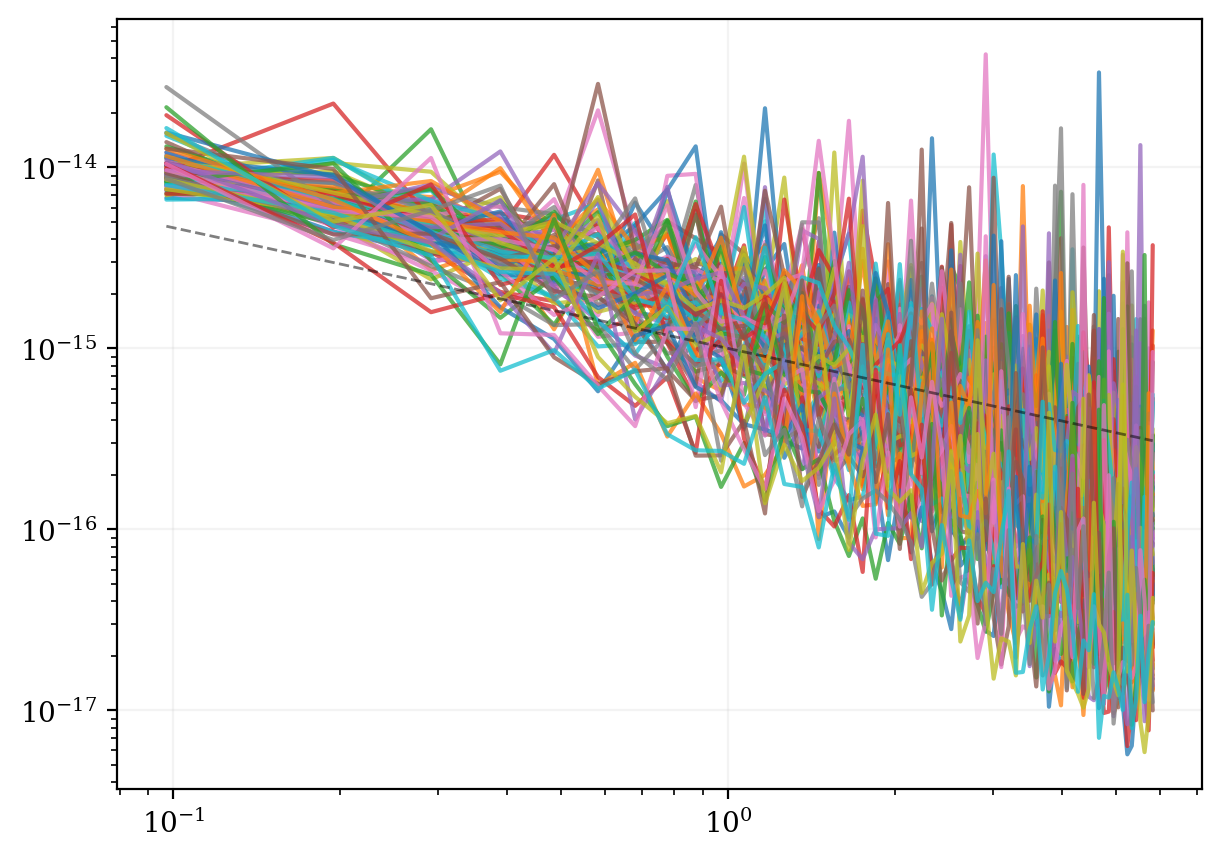

In [59]:
from holodeck import cosmo, plot, utils
from holodeck.constants import GYR, MSOL, PC, YR
from holodeck.librarian import posterior_populations as postpop
# Number of realizations to plot
plot_num_reals = 10
plot_num_params = 10
# Number of loudest-binaries-per-bin to plot
plot_num_loudest = 0

# ---- Load data

# Frequency bin edges, in units of [1/sec], for orbital frequencies
fobs_orb_edges = data["fobs_orb_edges"][0]  # Just need the first one, they're all the same
# convert to GW frequency centers (assuming circular orbits)
fobs_orb_cents = 0.5 * (fobs_orb_edges[1:] + fobs_orb_edges[:-1])
fobs_gw_cents = 2.0 * fobs_orb_cents * YR

# Characteristic strains of the L loudest binaries in each of F frequency bins for each of R realizations
# shape: (NParReals, F, R, L)
hc_ss = data["hc_ss"]
npar_reals, nfreqs, nreals, nloudest = hc_ss.shape 
# Characteristic strain of all *other* binaries (i.e. All minus L)
# shape: (NParReals, F, R)
hc_bg = data["hc_bg"]

# can't plot more elements than we have in the data
plot_num_reals = np.minimum(plot_num_reals, nreals)
plot_num_params = np.minimum(plot_num_params, npar_reals)
plot_num_loudest = np.minimum(plot_num_loudest, nloudest)

# ---- Plot GW signals

fig, ax = holo.plot.figax()
for nr in range(plot_num_params):
    for rr in range(plot_num_reals):
        # this is the combined GWs from all binaries except `L` loudest in each frequency bin
        bg = hc_bg[nr, :, rr]
        # add back in the strains from the loudest binaries that we aren't plotting
        if nloudest > plot_num_loudest:
            fg = hc_ss[nr, :, rr, plot_num_loudest:]
            # Add in quadrature, summing over however many loudest binaries remain
            bg = np.sqrt(bg**2 + np.sum(fg**2, axis=-1))
    
        (hh,) = ax.plot(fobs_gw_cents, bg, alpha=0.75)
        for ll in range(plot_num_loudest):
            ax.scatter(
                fobs_gw_cents, hc_ss[nr, :, rr, ll], color=hh.get_color(), s=10, alpha=0.5
            )

# Plot a -2/3 power-law of amplitude 1e-15 for reference
hc_plaw = 1.0e-15 * np.power(fobs_gw_cents, -2.0 / 3.0)
ax.plot(fobs_gw_cents, hc_plaw, "k--", alpha=0.5, lw=1.0)

plt.show()

In [68]:
len(hc_plaw)

60

In [60]:
holo.__version__ #holodeck-gw = ">=1.5.2,<2"

'1.5.2'

In [61]:
#do slices 

In [62]:
#Tspan = 16.03*365.25*24*3600
hc_bg = np.array(data['hc_bg'])
hc_ss = np.array(data['hc_ss'])
fobs = np.linspace(1/Tspan, 60/Tspan, 60)
dfobs=np.ones(len(fobs))*(fobs[1]-fobs[0])
silver = '#cebebe'
dots = '#E55812'
hc_bg.shape, hc_ss.shape

((100, 60, 10), (100, 60, 10, 1))

##### the hc_bg and hc_ss in the json file are shaped (nfreqs, nreals) and (nfreqs, nreals, nloudest)
### hc_bg:(nfreqs, nreals) --> 60, 50
### hc_ss: (nfreqs, nreals, nloudest) --> 60, 50, 50

### Anjana: No they are not for Dave's population. 
### They are in fact:

### hc_bg: (NParReals, F, R) --> (100, 60, 10)
### hc_ss: (npar_reals, nfreqs, nreals, nloudest) --> (100, 60, 10, 1)

### Need to change what happens below carefully to use the right quantities.

In [67]:
## lets put the background back in :))
full_hc_bg = np.sqrt(hc_bg**2 + np.sum(hc_ss**2, axis=-1))

In [64]:
# GWB as reported in NG15 GWB paper 
fakeA = 1e-15
fakegamma = 4.33
fake_alpha = (3. - fakegamma) / 2.
fake_power = hsen.S_h(A=fakeA, alpha=fake_alpha, freqs=freqs)
fake_hc_pl = np.sqrt(fake_power*freqs)

ValueError: x and y must be the same size

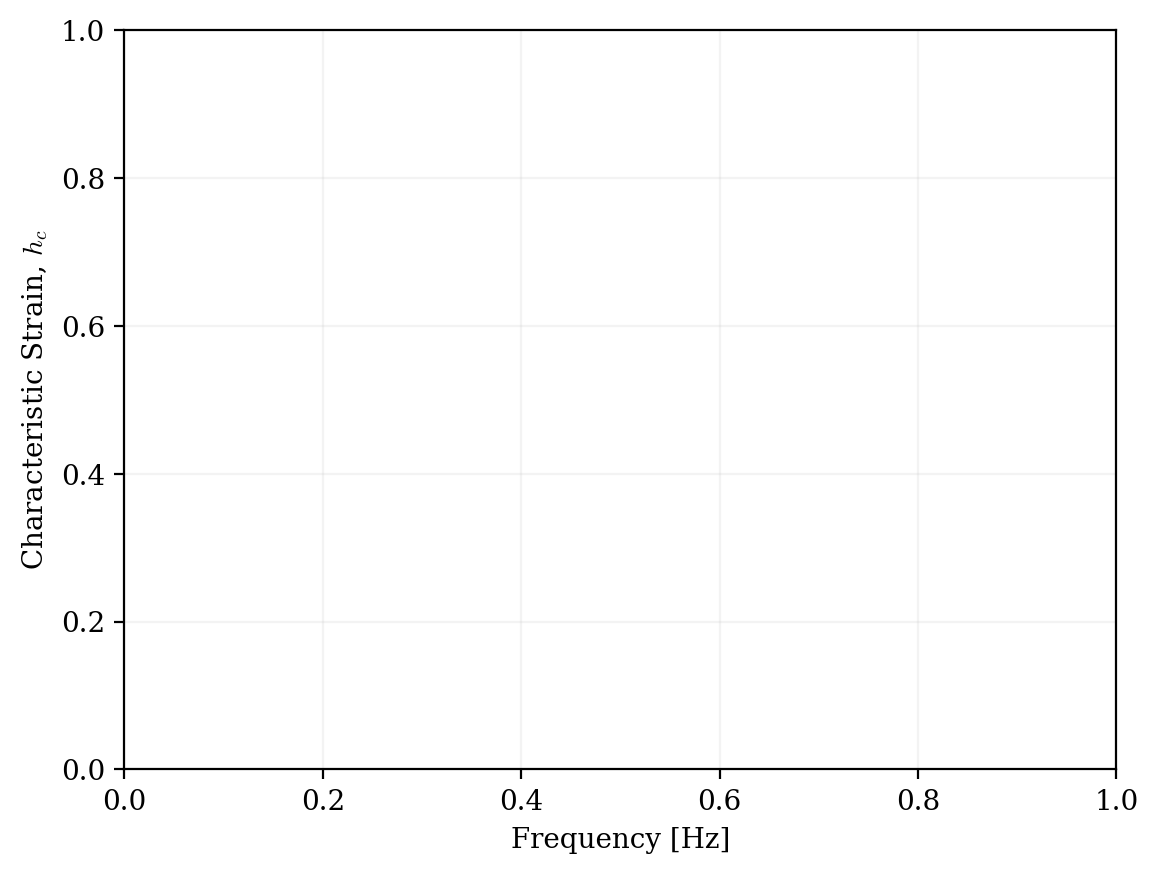

In [65]:
YR=365.25*24*3600
nreals = 10
#colors = cm.rainbow(np.linspace(0,1,nreals))
plt.xlabel('Frequency [Hz]')
plt.ylabel('Characteristic Strain, $h_c$')
for rr in range(nreals):
    if(rr==0):
        label_bg = 'Realization GWB'
        label_ss = 'Realization Loudest Source'
    else:
        label_bg = None
        label_ss = None
    #plt.loglog(fobs_gw_cents, full_hc_bg[:,rr], alpha=0.5, label=label_bg, color="grey")#color=colors[rr])
    plt.scatter(fobs_gw_cents, hc_ss[:,rr,0], alpha=0.2, label=label_ss, color=dots)#color=colors[rr])
plt.loglog(freqs, fake_hc_pl, color='k', linestyle=':', label='Injected GWB')
plt.xlim(1.5e-9, 1e-7)
plt.ylim(0.5e-16, 0.6e-13)
#plt.loglog(fobs, np.median(hc_bg, axis=1), color='k')
plt.legend(fontsize=8,loc=3)
plt.show()

In [ ]:
import seaborn as sns
import matplotlib as mpl
yearly_years = years
mpl.rcParams['xtick.labelsize'] = 14
mpl.rcParams['ytick.labelsize'] = 14

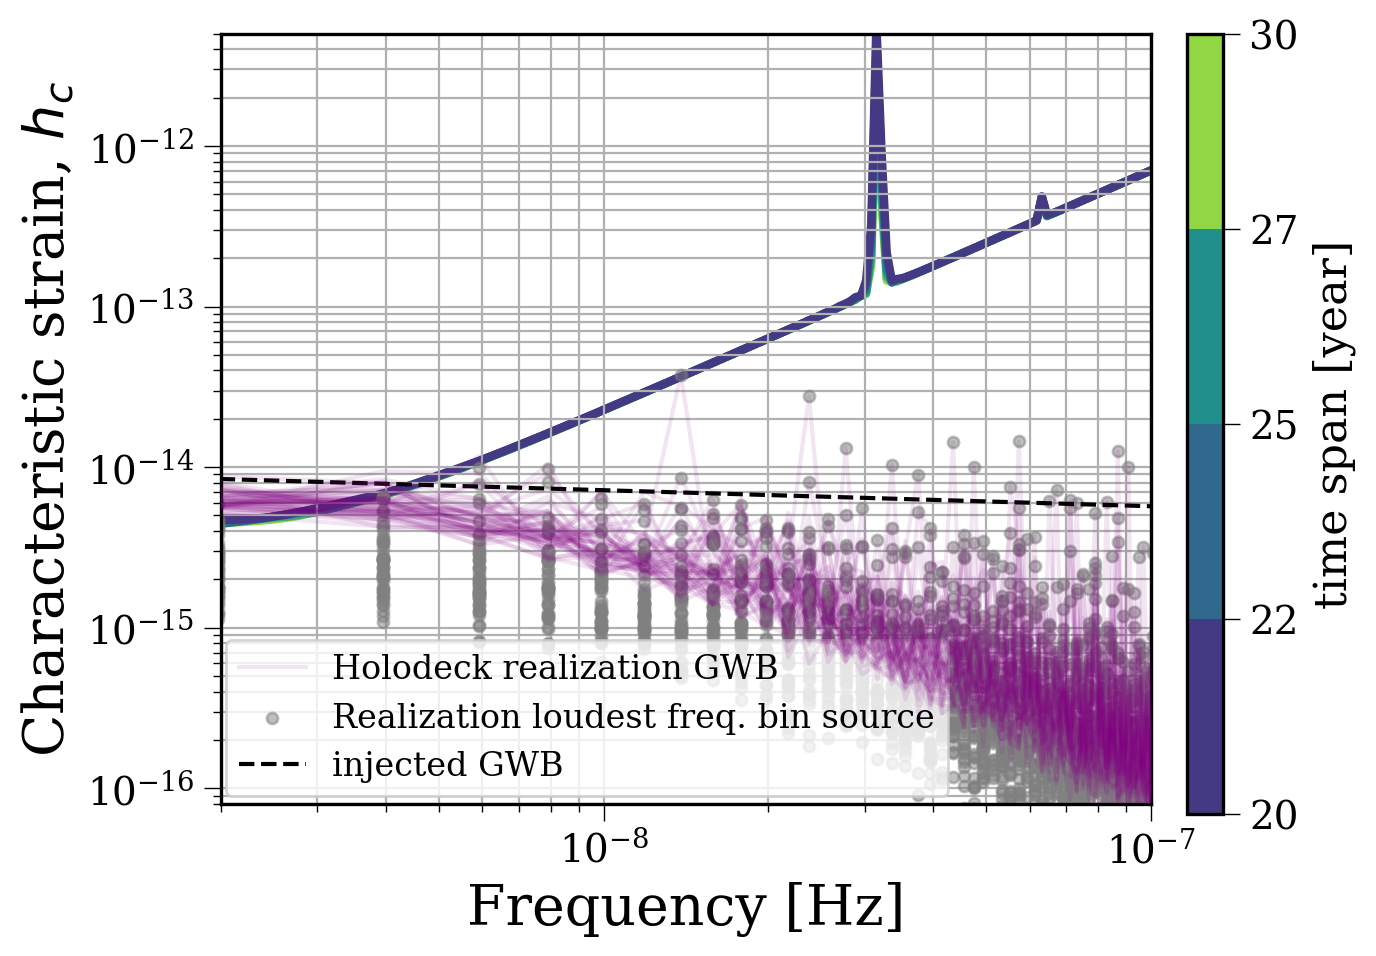

In [ ]:
# Plot GWB SC with realizations on it
#color_map = plt.cm.jet_r(np.linspace(0,1,len(yearly_years)))
color_map = sns.color_palette('viridis_r', n_colors = len(yearly_years), as_cmap=False,)
cmap = mpl.colors.LinearSegmentedColormap.from_list(
    'Custom cmap', np.flip(color_map, axis=0), len(color_map))
fig = plt.figure(figsize=[6,5])
nreals = np.min([100, len(hc_bg[0])])
colors = cm.rainbow(np.linspace(0,1,nreals))
plt.grid(which='both',zorder=0)
for i, sc in enumerate(sky_maps):
    linewidth=3
    plt.loglog(sc.freqs, 2*np.mean(sc.h_c, axis=1), color = color_map[i], linewidth=linewidth, alpha=1,zorder=1)
    #plt.loglog(sc.freqs, sky_ave_detect(sc), color = color_map[i], linewidth=linewidth, alpha=1,zorder=1) 
for rr in range(nreals):
    if(rr==0):
        label_bg = 'Holodeck realization GWB'
        label_ss = 'Realization loudest freq. bin source'
    else:
        label_bg = None
        label_ss = None
    plt.loglog(fobs, full_hc_bg[:,rr], alpha=0.1, label=label_bg, color="purple", zorder=502)#color=colors[rr])
    plt.scatter(fobs, hc_ss[:,rr,0], alpha=0.5, label=label_ss, color='gray', zorder=2)#color=colors[rr])
plt.loglog(freqs, inj_gwb_hc, color='k', linestyle='--', label='injected GWB', zorder=5 )
plt.legend(loc=(0.005,0.01), fontsize=12)
plt.xlabel('Frequency [Hz]', fontsize=20)
plt.ylabel('Characteristic strain, $h_c$', fontsize=20)
plt.xlim((2e-9, 1e-7))
plt.ylim((8e-17, 5e-12))
ax2 = fig.add_axes([0.93, 0.1, 0.03, 0.78])
norm = mpl.colors.BoundaryNorm(yearly_years, cmap.N)
cbar = mpl.colorbar.ColorbarBase(ax2, cmap=cmap,
    spacing='proportional', format='%1i', norm=norm, boundaries=np.flip(yearly_years))
ax2.set_ylabel('time span [year]', fontsize=16, labelpad=5)
#plt.savefig(f'{fig_dir}/GPTA_40yr_hc_evolution_w_sims.pdf', dpi=600, bbox_inches='tight', facecolor='white')
plt.show()
plt.close()

In [ ]:
#this line gets the SM index of the data set frequency bins (this is the same for all realizations)
freq_indcs = np.array([np.argmin(abs(freqs-fobs[ii])) for ii in range(len(fobs))])
# gets the indices of the best and worst sky position (at the first frequency)

idx_of_worst_sky_position = np.argmax(sky_maps[14].S_effSky[0])
idx_of_best_sky_position = np.argmin(sky_maps[14].S_effSky[0])
yearly_years[14]

In [ ]:
# convert our characteristic strain to strain amplitude
out_of_order_array = np.array([np.array([holo.utils.char_strain_to_strain_amp(hc_ss[:,realization, loudest], fobs, dfobs) for loudest in range(len(hc_ss[0,0,:]))]) for realization in range(len(hc_ss[0,:,0]))])
h_amp_ss = np.swapaxes(out_of_order_array, 0,1).T
h_amp_ss.shape

(60, 50, 50)

In [ ]:
# get best and worst sky locations
idx_of_worst_sky_position = np.argmax(sky_maps[0].S_effSky[0])
idx_of_best_sky_position = np.argmin(sky_maps[0].S_effSky[0])

In [ ]:
h_amp_ss.shape

(60, 50, 50)

In [ ]:
yearly_years

[20.0, 22.5, 25.0, 27.5, 30.0]

In [ ]:
yum = np.array([np.array([[sky_maps[ig].SNR(h_amp_ss[f, r, 0])[f,idx_of_best_sky_position] for r in range(50)] for f in range(60)]) for ig in range(len(yearly_years))])

In [ ]:
yum.shape

(5, 60, 50)

In [ ]:
yum2 = np.max(yum, axis=1)
yum2.shape

(5, 50)

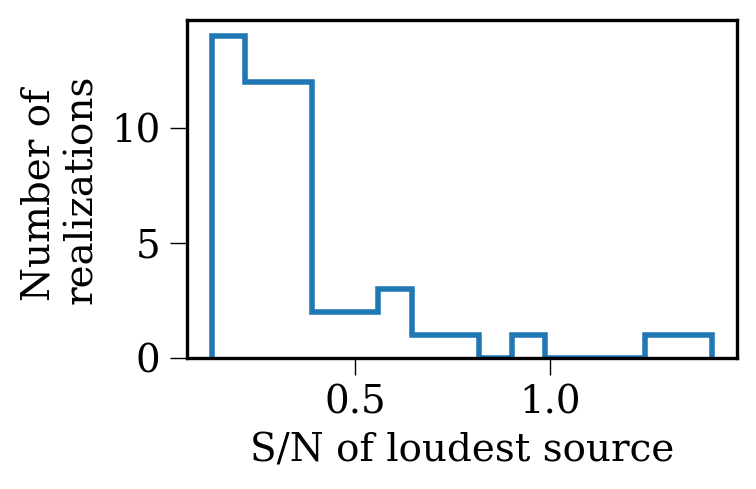

In [ ]:
for i, y in enumerate([yum2[0]]):
    plt.hist(y, histtype='step', bins=15, color=f'C{i}', linewidth=2)
plt.xlabel('S/N of loudest source', fontsize=14)
plt.ylabel('Number of \nrealizations', fontsize=14)
plt.show()

In [ ]:
yum.shape

(5, 60)

In [ ]:

best_sky_loc_snr2=0.5*np.array([[SMs[-1].SNR(h_amp_ss[inx,realization,0])[freq_bin_idxs[inx],idx_of_best_sky_position] for inx in range(len(fobs))] for realization in range(len(h_amp_ss[0]))]).T
